In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df = pd.read_csv('/content/cs-training.csv')


In [3]:
df.drop(columns=['Unnamed: 0'], inplace=True)


In [5]:
df.fillna({
    'MonthlyIncome': df['MonthlyIncome'].median(),
    'NumberOfDependents': df['NumberOfDependents'].median()
}, inplace=True)

In [6]:
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
y_pred = model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9370666666666667
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     28044
           1       0.55      0.20      0.29      1956

    accuracy                           0.94     30000
   macro avg       0.75      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000



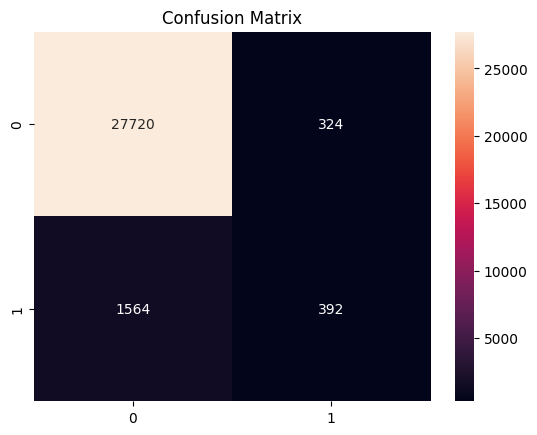

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

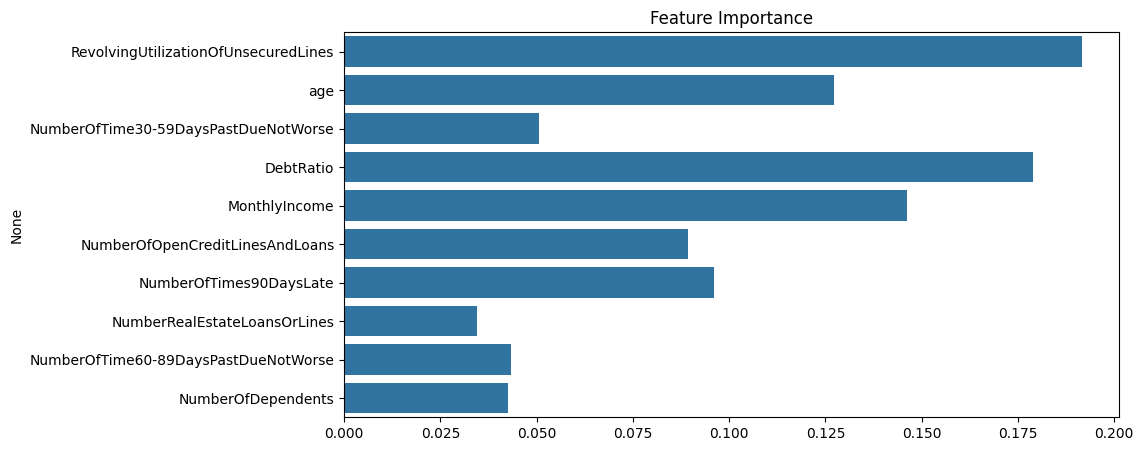

In [13]:
importances = model.feature_importances_
feat_names = X.columns
plt.figure(figsize=(10,5))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance")
plt.show()

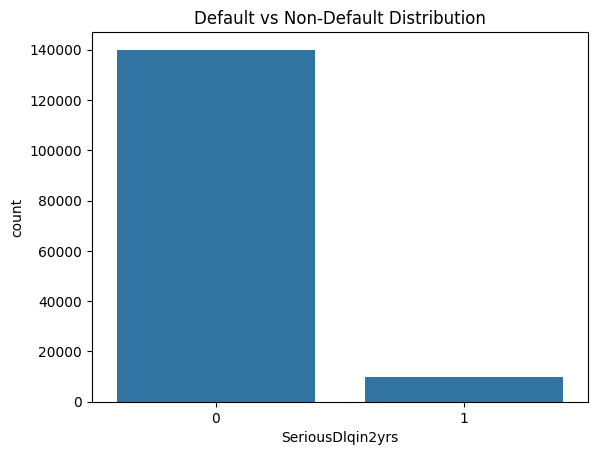

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title("Default vs Non-Default Distribution")
plt.show()

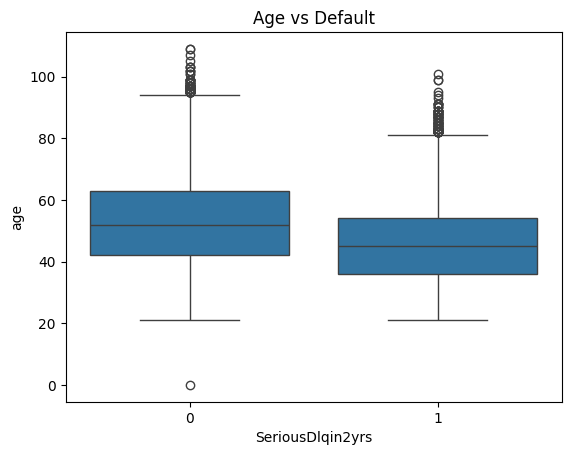

In [15]:
sns.boxplot(x='SeriousDlqin2yrs', y='age', data=df)
plt.title("Age vs Default")
plt.show()

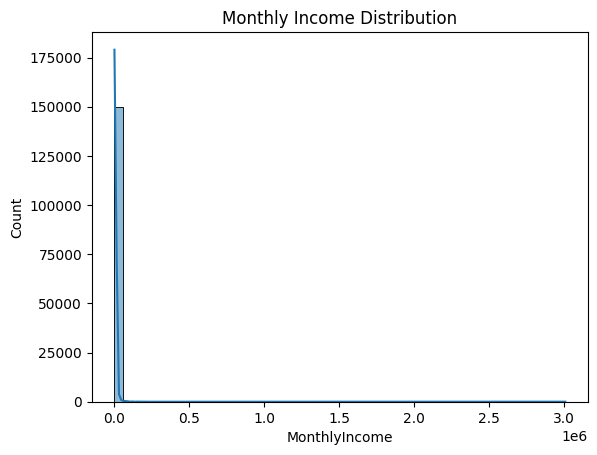

In [16]:
sns.histplot(df['MonthlyIncome'], bins=50, kde=True)
plt.title("Monthly Income Distribution")
plt.show()

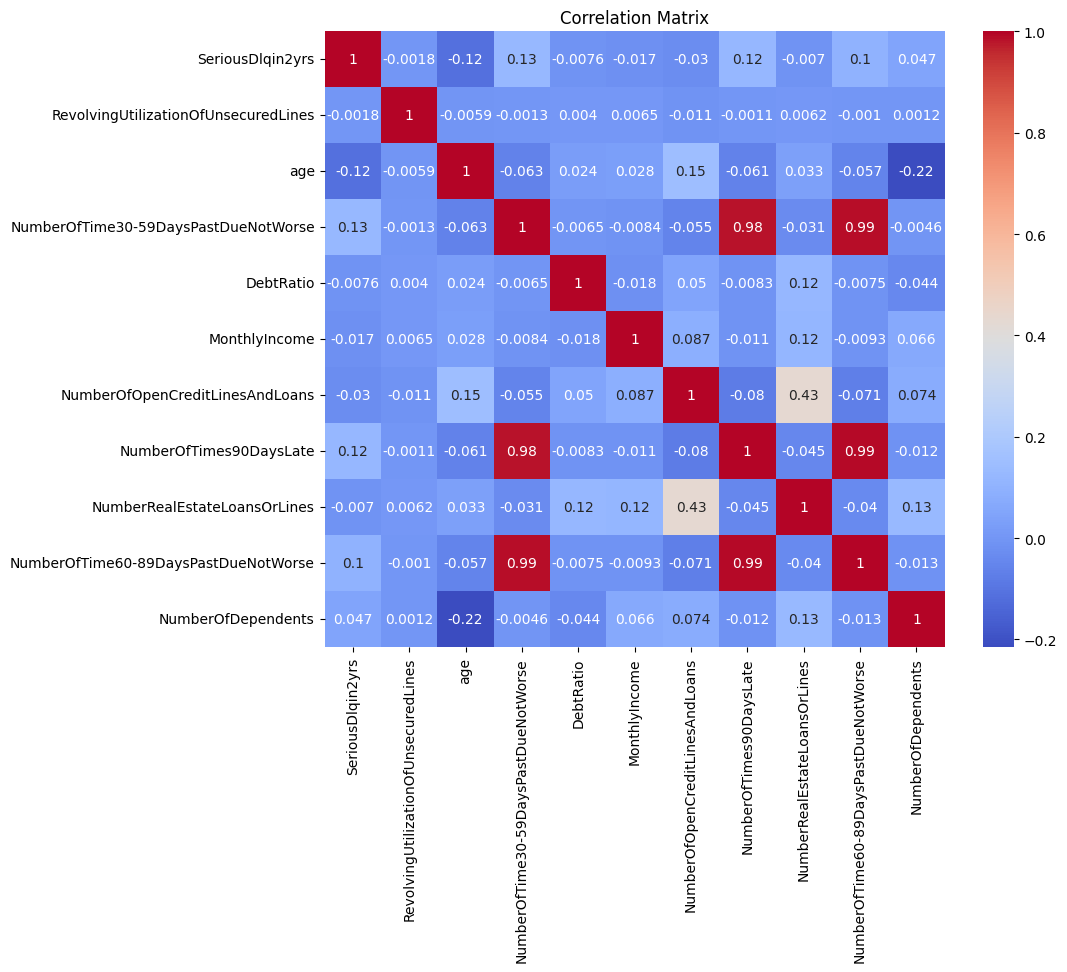

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

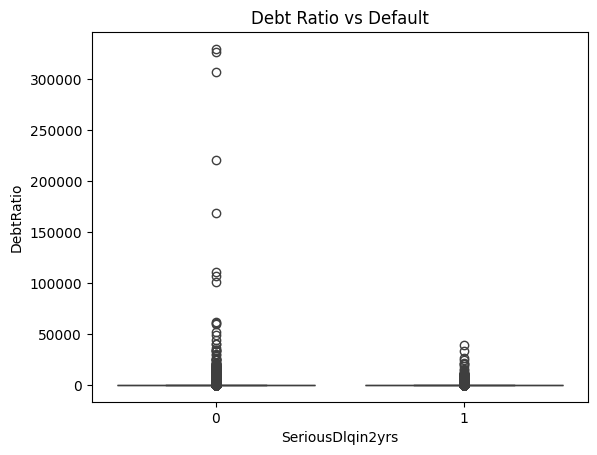

In [18]:
sns.boxplot(x='SeriousDlqin2yrs', y='DebtRatio', data=df)
plt.title("Debt Ratio vs Default")
plt.show()

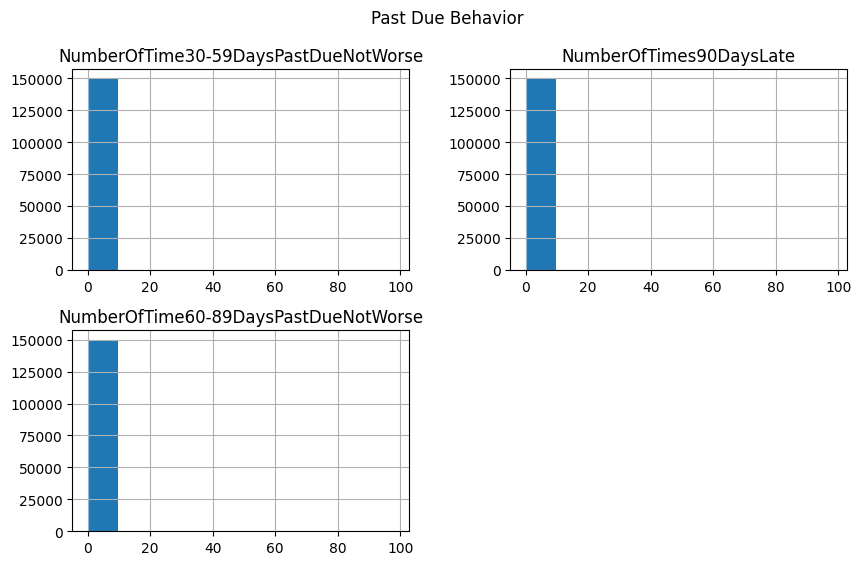

In [19]:
cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

df[cols].hist(figsize=(10,6))
plt.suptitle("Past Due Behavior")
plt.show()

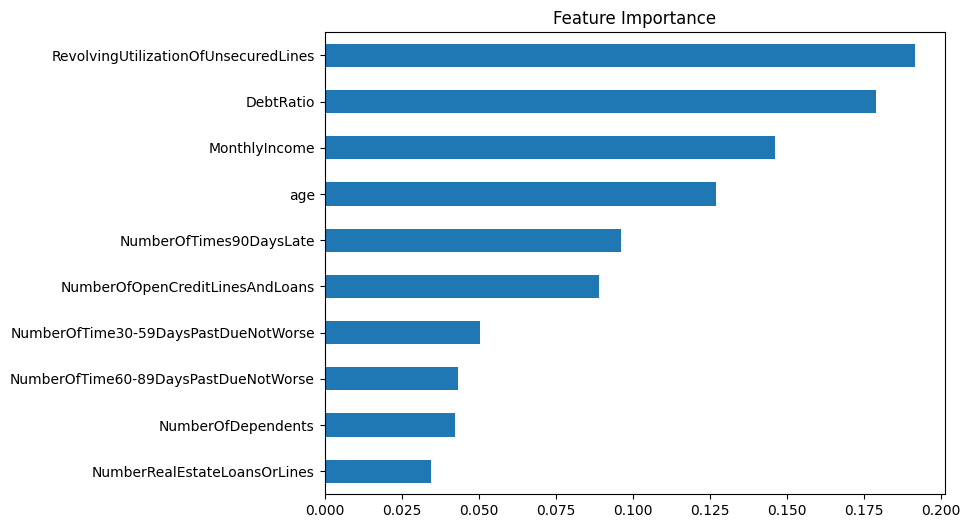

In [21]:
import pandas as pd

feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

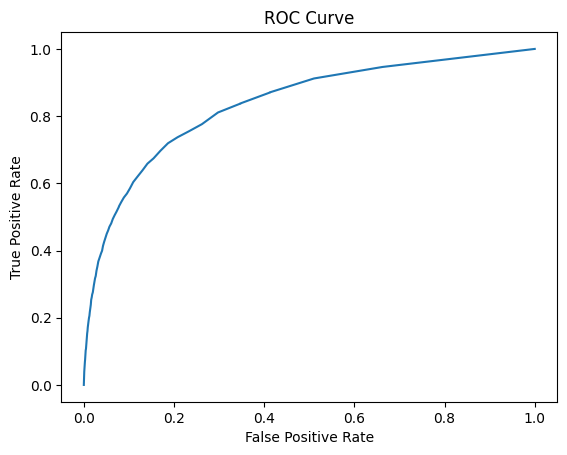

In [22]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

/tmp/ipykernel_1378/2785381445.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['SeriousDlqin2yrs'].mean().plot(kind='bar')


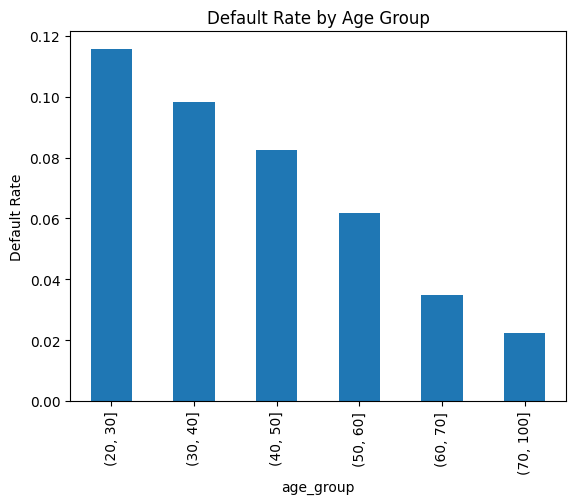

In [23]:
df['age_group'] = pd.cut(df['age'], bins=[20,30,40,50,60,70,100])

df.groupby('age_group')['SeriousDlqin2yrs'].mean().plot(kind='bar')
plt.title("Default Rate by Age Group")
plt.ylabel("Default Rate")
plt.show()

In [26]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))
from google.colab import files
files.download('model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>